# `effectful_mcmc` quickstart

A walkthrough of the bridge over `numpyro.infer.NUTS` for `effectful` models. Three demos:

1. **Bayesian linear regression** on a synthetic dataset — basic `sample`/`MCMC`/`NUTS` usage.
2. **Eight schools** (Rubin, 1981) — a real hierarchical-Bayes benchmark, written in the per-element idiom (one explicit `sample` per school).
3. **Counterfactual via `Intervene`** — what the bridge buys you over plain NumPyro: handlers compose with the inference layer, so you can intervene on a named site mid-program and re-run inference under the intervention.

Distributions come from `effectful.handlers.numpyro` (term-aware: they accept both eager arrays and effectful terms in the same call). The primitives `sample`, `factor`, `param`, `deterministic` are `@defop`s — interceptable by any effectful handler stack.

Run locally:

```bash
pip install -e .
jupyter notebook docs/quickstart.ipynb
```

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
import numpy as np

from effectful.handlers.numpyro import Normal, HalfNormal
from effectful.ops.semantics import handler

from effectful_mcmc import sample, MCMC, NUTS, Intervene

jax.config.update("jax_platform_name", "cpu")  # demo is small enough that CPU is fastest

/Users/datnguyen/HMC_NUTS_Effectful/effectful_mcmc/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Bayesian linear regression on synthetic data

Generate a small dataset with known parameters: $y = \alpha + \beta \cdot x + \varepsilon$, with $\alpha = 2.0$, $\beta = -1.5$, $\varepsilon \sim \mathcal{N}(0, 0.5)$. Then infer the posterior over $\alpha, \beta, \sigma$ and check we recover the truth.

The model uses `effectful.handlers.numpyro`'s `Normal`/`HalfNormal` so the priors over $\alpha$, $\beta$, $\sigma$ produce term-aware distributions that can plug back into the likelihood $\mathcal{N}(\alpha + \beta \cdot x,\ \sigma)$ with no glue code.

**Posterior access via Operation handles.** Each `sample(...)` call returns a *term* backed by a unique `Operation`. Returning those terms from the model lets you index `mcmc.get_samples()` by `term.op` directly — no string names to keep in sync. (Pass `name=` if you also want string-keyed access for ArviZ-style consumers or for `Intervene`; we'll do that in section 3.)

In [2]:
# Synthetic regression dataset
true_alpha, true_beta, true_sigma = 2.0, -1.5, 0.5
N = 50

key_data = jr.PRNGKey(0)
k_x, k_noise = jr.split(key_data)
x_data = jr.uniform(k_x, (N,), minval=-2.0, maxval=2.0)
y_data = true_alpha + true_beta * x_data + true_sigma * jr.normal(k_noise, (N,))

print(f"Generated {N} points with alpha={true_alpha}, beta={true_beta}, sigma={true_sigma}")

Generated 50 points with alpha=2.0, beta=-1.5, sigma=0.5


In [3]:
def linear_regression(x, y):
    alpha = sample(Normal(0.0, 10.0))
    beta  = sample(Normal(0.0, 10.0))
    sigma = sample(HalfNormal(2.0))
    sample(Normal(alpha + beta * x, sigma), obs=y)
    return alpha, beta, sigma                          # return per-site handles

mcmc = MCMC(NUTS(linear_regression), num_warmup=500, num_samples=1000, progress_bar=False)
mcmc.run(jr.PRNGKey(1), x_data, y_data)

# Posteriors keyed by the underlying Operation — `term.op` recovers it.
alpha_t, beta_t, sigma_t = mcmc.model_return_value
samples = mcmc.get_samples()

for term, label, true in [(alpha_t, "alpha", true_alpha),
                          (beta_t,  "beta",  true_beta),
                          (sigma_t, "sigma", true_sigma)]:
    post = samples[term.op]
    print(f"{label}: posterior mean = {float(post.mean()):+.3f}  "
          f"std = {float(post.std()):.3f}  (truth = {true:+.2f})")

alpha: posterior mean = +1.770  std = 0.081  (truth = +2.00)
beta: posterior mean = -1.477  std = 0.067  (truth = -1.50)
sigma: posterior mean = +0.568  std = 0.059  (truth = +0.50)


Posteriors recover the truth within ~1 posterior std. `mcmc.print_summary()` works the same as `numpyro.infer.MCMC.print_summary()` — the bridge forwards post-run attribute access via `__getattr__`. Since the sites are anonymous (no `name=`), the table is keyed by auto-synthesized site identifiers; pass `name=` to each `sample(...)` if you need ArviZ-shaped string keys.

In [4]:
mcmc.print_summary()


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
  _site_1168fd2e0     -1.48      0.07     -1.48     -1.58     -1.36    882.47      1.00
  _site_116927590      1.77      0.08      1.77      1.63      1.89    818.83      1.00
  _site_116931a60      0.57      0.06      0.56      0.47      0.65    981.31      1.00

Number of divergences: 0


### Posterior diagnostics

The standard NUTS-paper-style diagnostics (Hoffman & Gelman, 2014, JMLR — Figs. 7–8): per-parameter **trace plots** to confirm the chain mixed without sticking, and **marginal posteriors** with the data-generating truth overlaid as a vertical line. Below all three parameters get the same treatment.

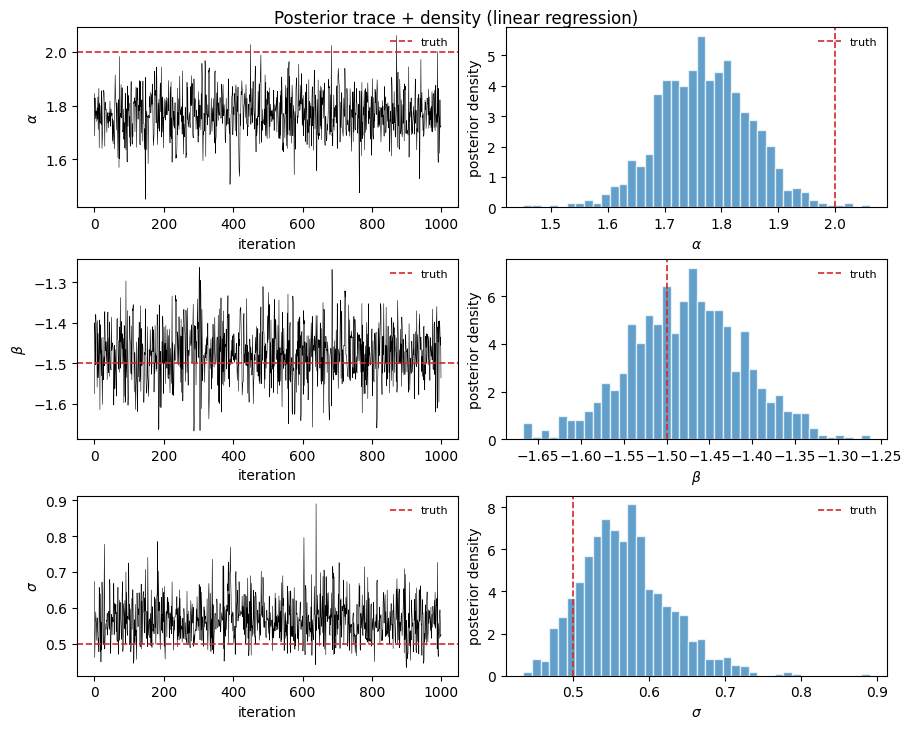

In [5]:
def trace_and_density(axes_row, draws, label, truth):
    ax_trace, ax_density = axes_row
    draws = np.asarray(draws)
    ax_trace.plot(draws, lw=0.4, color="black")
    ax_trace.axhline(truth, color="C3", lw=1.2, ls="--", label="truth")
    ax_trace.set_xlabel("iteration")
    ax_trace.set_ylabel(label)
    ax_trace.legend(loc="upper right", frameon=False, fontsize=8)

    ax_density.hist(draws, bins=40, density=True, color="C0", alpha=0.7, edgecolor="white")
    ax_density.axvline(truth, color="C3", lw=1.2, ls="--", label="truth")
    ax_density.set_xlabel(label)
    ax_density.set_ylabel("posterior density")
    ax_density.legend(loc="upper right", frameon=False, fontsize=8)

fig, axes = plt.subplots(3, 2, figsize=(9, 7), constrained_layout=True)
for row, (term, label, truth) in enumerate([
    (alpha_t, r"$\alpha$", true_alpha),
    (beta_t,  r"$\beta$",  true_beta),
    (sigma_t, r"$\sigma$", true_sigma),
]):
    trace_and_density(axes[row], samples[term.op], label, truth)
fig.suptitle("Posterior trace + density (linear regression)", y=1.02)
plt.show()

## 2. Eight schools (Rubin, 1981) — hierarchical Bayes

Classical hierarchical-Bayes benchmark: eight schools each report an estimated treatment effect $y_j$ with reported standard error $\sigma_j$. The hierarchical model partially pools the school-level effects toward a population mean $\mu$ with population scale $\tau$:

$$
\mu \sim \mathcal{N}(0, 10) \\
\tau \sim \mathrm{HalfNormal}(10) \\
\theta_j \sim \mathcal{N}(\mu, \tau) \\
y_j \sim \mathcal{N}(\theta_j, \sigma_j)
$$

Written in the per-element idiom — one explicit `sample` per school — which the bridge supports today as a hierarchical-model story (no `plate` machinery needed).

In [6]:
# Rubin (1981) data
y_obs    = jnp.array([28.0,  8.0, -3.0,  7.0, -1.0,  1.0, 18.0, 12.0])
sigma_obs = jnp.array([15.0, 10.0, 16.0, 11.0,  9.0, 11.0, 10.0, 18.0])
J = len(y_obs)

def eight_schools(y, sigma):
    mu  = sample(Normal(0.0, 10.0), name="mu")
    tau = sample(HalfNormal(10.0),   name="tau")
    for j in range(J):
        theta_j = sample(Normal(mu, tau), name=f"theta_{j}")
        sample(Normal(theta_j, sigma[j]), obs=y[j], name=f"y_{j}")

mcmc8 = MCMC(NUTS(eight_schools), num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc8.run(jr.PRNGKey(2), y_obs, sigma_obs)
samples8 = mcmc8.get_samples_by_name()

print(f"mu   posterior: mean = {float(samples8['mu'].mean()):+.2f}  std = {float(samples8['mu'].std()):.2f}")
print(f"tau  posterior: mean = {float(samples8['tau'].mean()):+.2f}  std = {float(samples8['tau'].std()):.2f}")
print("per-school theta posteriors:")
for j in range(J):
    th = samples8[f"theta_{j}"]
    print(f"  school {j}: mean = {float(th.mean()):+6.2f}  std = {float(th.std()):.2f}  (raw y_{j} = {float(y_obs[j]):+.1f})")

mu   posterior: mean = +5.92  std = 3.03
tau  posterior: mean = +2.33  std = 3.15
per-school theta posteriors:
  school 0: mean =  +6.99  std = 4.66  (raw y_0 = +28.0)
  school 1: mean =  +6.09  std = 3.97  (raw y_1 = +8.0)
  school 2: mean =  +5.57  std = 4.41  (raw y_2 = -3.0)
  school 3: mean =  +6.01  std = 4.03  (raw y_3 = +7.0)
  school 4: mean =  +5.28  std = 4.03  (raw y_4 = -1.0)
  school 5: mean =  +5.45  std = 4.04  (raw y_5 = +1.0)
  school 6: mean =  +6.89  std = 4.11  (raw y_6 = +18.0)
  school 7: mean =  +6.09  std = 4.57  (raw y_7 = +12.0)


Note the **shrinkage**: per-school posterior means are pulled toward $\mu \approx 7$ from the raw observations. School 0 ($y_0 = +28$) is the most dramatic — the hierarchical prior pulls its $\theta_0$ down because the population-scale $\tau$ is small enough that $28$ looks like a noise excursion.

### Eight-schools forest plot

The textbook visualization for hierarchical Bayes — each school's posterior $\theta_j$ as a credible interval, with the raw observation $y_j \pm \sigma_j$ alongside for contrast. The amount the credible interval is pulled toward the population mean $\mu$ is the **shrinkage** the model induces.

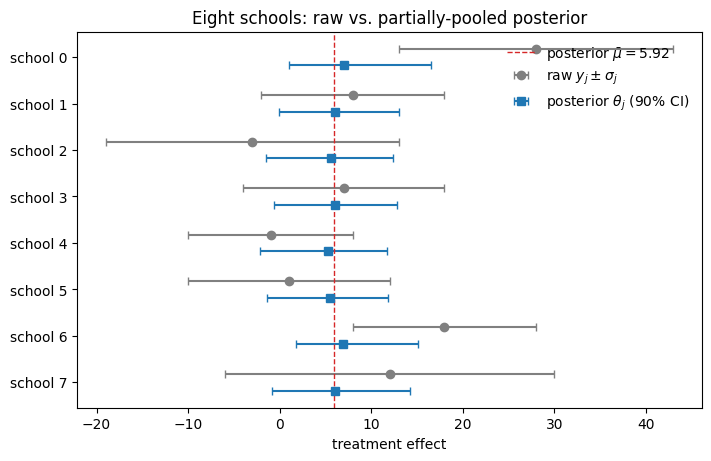

In [7]:
theta_means = np.array([float(samples8[f"theta_{j}"].mean())            for j in range(J)])
theta_lo    = np.array([float(np.quantile(samples8[f"theta_{j}"], 0.05)) for j in range(J)])
theta_hi    = np.array([float(np.quantile(samples8[f"theta_{j}"], 0.95)) for j in range(J)])
mu_mean     = float(samples8["mu"].mean())

y_arr = np.asarray(y_obs)
s_arr = np.asarray(sigma_obs)
yloc  = np.arange(J)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
# raw observations with reported standard errors
ax.errorbar(y_arr, yloc - 0.18, xerr=s_arr, fmt="o", color="gray", capsize=3,
            label=r"raw $y_j \pm \sigma_j$")
# posterior 90% credible intervals for each theta_j
ax.errorbar(theta_means, yloc + 0.18,
            xerr=[theta_means - theta_lo, theta_hi - theta_means],
            fmt="s", color="C0", capsize=3, label=r"posterior $\theta_j$ (90% CI)")
ax.axvline(mu_mean, color="C3", ls="--", lw=1, label=fr"posterior $\bar{{\mu}} = {mu_mean:.2f}$")
ax.set_yticks(yloc)
ax.set_yticklabels([f"school {j}" for j in range(J)])
ax.invert_yaxis()
ax.set_xlabel("treatment effect")
ax.set_title("Eight schools: raw vs. partially-pooled posterior")
ax.legend(loc="upper right", frameon=False)
plt.show()

## 3. Counterfactual via `Intervene` — what the bridge buys you

Plain NumPyro has `numpyro.handlers.substitute` which can fix a site to a value, but it's a NumPyro-specific mechanism that doesn't compose with other effectful handlers, and it doesn't have a clean story for "intervene then re-run inference under the intervention".

Here's the bridge's story:

- `Intervene(name, value)` is an effectful handler. It intercepts the `sample` defop and overrides the named site.
- Wrap the model in `with handler(Intervene(...))` and pass the wrapped model to `MCMC(NUTS(...))`. The intervention survives all the way through compile-time tracing and per-step potential evaluation.
- The intervened site is **removed** from the posterior — the user already passed the value in; they don't need MCMC to round-trip it.
- The remaining sites' posteriors **tighten** because they now condition on the intervention as if it were observed.

We demonstrate by asking: *what would the posterior over $\alpha$ and $\beta$ look like in our linear regression if we knew the noise level was exactly $\sigma = 0.5$?*

(Sites that are *intervened* need string names — `Intervene("sigma", ...)` references the target by string — so for this section we re-introduce `name=` only on the site we plan to intervene.)

In [8]:
# Re-define the regression with `name="sigma"` on the site we intend to intervene.
# Sites we won't intervene on stay anonymous.
def linear_regression_named_sigma(x, y):
    alpha = sample(Normal(0.0, 10.0))
    beta  = sample(Normal(0.0, 10.0))
    sigma = sample(HalfNormal(2.0), name="sigma")
    sample(Normal(alpha + beta * x, sigma), obs=y)
    return alpha, beta, sigma

def regression_with_sigma_fixed(x, y):
    with handler(Intervene("sigma", jnp.array(0.5))):
        return linear_regression_named_sigma(x, y)

# Baseline run (sigma inferred), for comparison:
mcmc_base = MCMC(NUTS(linear_regression_named_sigma),
                 num_warmup=500, num_samples=1000, progress_bar=False)
mcmc_base.run(jr.PRNGKey(1), x_data, y_data)
base_alpha, base_beta, _ = mcmc_base.model_return_value
base = mcmc_base.get_samples()

# Intervened run (sigma held at 0.5):
mcmc_fixed = MCMC(NUTS(regression_with_sigma_fixed),
                  num_warmup=500, num_samples=1000, progress_bar=False)
mcmc_fixed.run(jr.PRNGKey(3), x_data, y_data)
fix_alpha, fix_beta, _ = mcmc_fixed.model_return_value
fixed = mcmc_fixed.get_samples()

print("baseline (sigma inferred) vs. intervened (sigma = 0.5 fixed):\n")
print(f"{'param':>10s}  {'baseline mean +/- std':>24s}  {'intervened mean +/- std':>25s}  {'std ratio':>10s}")
print("-" * 79)
for label, b_t, i_t in [("alpha", base_alpha, fix_alpha), ("beta", base_beta, fix_beta)]:
    b = base[b_t.op];   i = fixed[i_t.op]
    b_mean, b_std = float(b.mean()), float(b.std())
    i_mean, i_std = float(i.mean()), float(i.std())
    print(f"{label:>10s}  {b_mean:+.3f} +/- {b_std:.3f}          "
          f"{i_mean:+.3f} +/- {i_std:.3f}            {i_std/b_std:.3f}")

print(f"\nintervened-sigma samples_by_name keys: {sorted(mcmc_fixed.get_samples_by_name().keys())}")
print("  ('sigma' is absent -- it's the intervened site, removed from posterior)")

baseline (sigma inferred) vs. intervened (sigma = 0.5 fixed):

     param     baseline mean +/- std    intervened mean +/- std   std ratio
-------------------------------------------------------------------------------
     alpha  +1.771 +/- 0.083          +1.771 +/- 0.070            0.847
      beta  -1.481 +/- 0.065          -1.481 +/- 0.055            0.849

intervened-sigma samples_by_name keys: ['_site_118eaa3c0', '_site_118eabe60']
  ('sigma' is absent -- it's the intervened site, removed from posterior)


Posteriors over $\alpha$ and $\beta$ are essentially unchanged in mean (the data already identifies them well) but slightly tighter when $\sigma$ is held fixed, because the inferred model no longer has to absorb noise-level uncertainty into the slope/intercept posterior.

The point of this last demo isn't the numerical effect — it's that `Intervene` is **just a handler**. It's a tiny class (~10 LOC, in `effectful_mcmc/__init__.py`) that intercepts the abstract `sample` defop. The same handler works under `MCMC`, under prior simulation (no MCMC at all), under SVI, and under any custom inference scheme that routes through `sample`. There's no MCMC-specific intervention API to learn — write the handler once, use it everywhere.

Custom handlers (conditioning, masking, ablations, projections, ...) follow the same pattern: subclass `ObjectInterpretation`, decorate methods with `@implements(sample)` / `@implements(factor)` / etc., and `with handler(MyHandler())` to stack them around the model.

### Counterfactual posterior comparison

Overlay the baseline and intervened marginal posteriors for $\alpha$ and $\beta$. The intervened densities are visibly tighter than the baseline ones — the inference no longer absorbs noise-level uncertainty into the slope/intercept posterior.

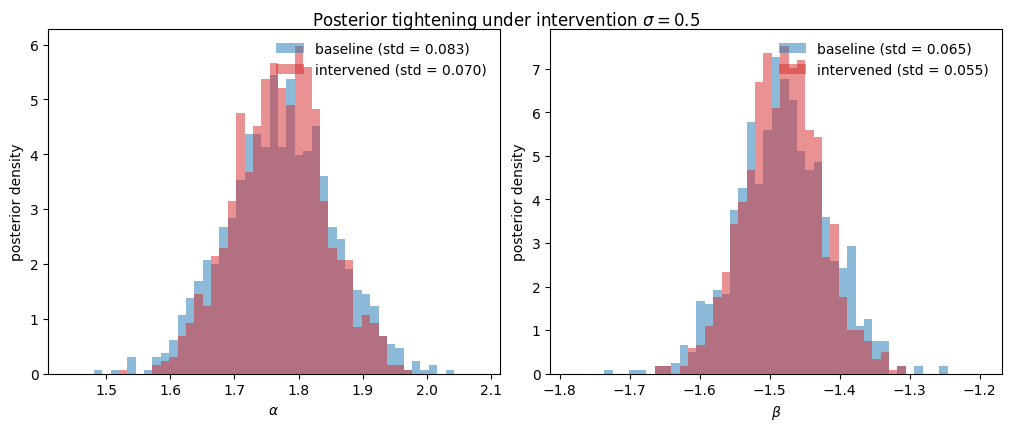

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, label, b_t, i_t in [
    (axes[0], r"$\alpha$", base_alpha, fix_alpha),
    (axes[1], r"$\beta$",  base_beta,  fix_beta),
]:
    b = np.asarray(base[b_t.op])
    i = np.asarray(fixed[i_t.op])
    bins = np.linspace(
        min(b.min(), i.min()) - 0.05,
        max(b.max(), i.max()) + 0.05,
        50,
    )
    ax.hist(b, bins=bins, density=True, alpha=0.5, color="C0",
            label=fr"baseline (std = {b.std():.3f})")
    ax.hist(i, bins=bins, density=True, alpha=0.5, color="C3",
            label=fr"intervened (std = {i.std():.3f})")
    ax.set_xlabel(label)
    ax.set_ylabel("posterior density")
    ax.legend(loc="upper right", frameon=False)
fig.suptitle(r"Posterior tightening under intervention $\sigma = 0.5$", y=1.04)
plt.show()

## Where to go next

- `tests/test_composition.py` — the differentiating tests: in-trace intervention, `fwd()` correctness, handler-nesting composition, hierarchical eight-schools, symbolic-indexing under MCMC.
- `tests/test_distributions.py` — every distribution in `effectful.handlers.numpyro` certified through NUTS (modulo discrete-skip and a structural `Delta` exception).
- `docs/biject_to_compatibility.md` — `biject_to` spike output: which distributions need workarounds for transform-based inference.